# Assignment 9 — Bank Marketing Classification Mini-Project

**Objective:** Predict whether a customer subscribes to a term deposit (`y`: yes/no) after a phone marketing campaign.
**Dataset:** UCI Bank Marketing (41,188 rows, 21 columns).

## 0 — Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print('Setup complete.')

Setup complete.


---
## 1 — Data Loading & Inspection

In [2]:
df = pd.read_csv('bank-marketing-dataset-full.csv', sep=';')
print(f'Shape: {df.shape}')
df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [4]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [5]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


---
## 2 — Exploratory Data Analysis (EDA)

### 2.1 Target Variable Distribution

y
no     36548
yes     4640
Name: count, dtype: int64

Imbalance ratio (no:yes): 7.9:1


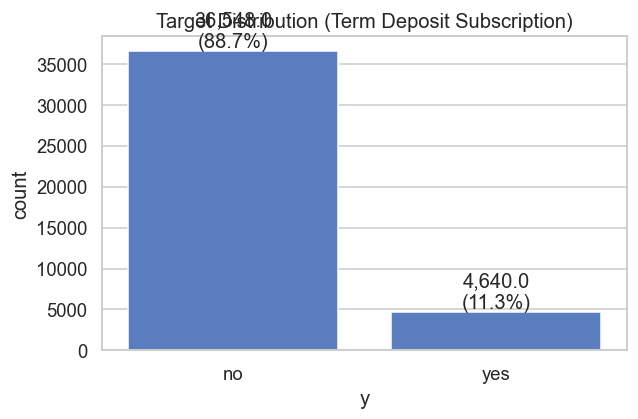

In [6]:
target_counts = df['y'].value_counts()
print(target_counts)
print(f'\nImbalance ratio (no:yes): {target_counts["no"] / target_counts["yes"]:.1f}:1')

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='y', data=df, order=['no', 'yes'], ax=ax)
ax.set_title('Target Distribution (Term Deposit Subscription)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}\n({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Observation:** The dataset is heavily imbalanced — roughly 88% "no" vs 12% "yes". Accuracy alone will be misleading; we must track precision, recall, F1, and ROC-AUC.

### 2.2 Identify Categorical vs Numeric Features

In [7]:
cat_cols = df.select_dtypes(include='object').columns.drop('y').tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()

print(f'Categorical ({len(cat_cols)}): {cat_cols}')
print(f'Numeric ({len(num_cols)}): {num_cols}')

Categorical (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


### 2.3 Missing Values Analysis ("unknown" entries)

In [8]:
unknown_counts = df.isin(['unknown']).sum()
unknown_counts = unknown_counts[unknown_counts > 0].sort_values(ascending=False)
print(unknown_counts)
print(f'\nTotal rows with at least one unknown: {df.isin(["unknown"]).any(axis=1).sum()}')

default      8597
education    1731
housing       990
loan          990
job           330
marital        80
dtype: int64

Total rows with at least one unknown: 10700


### 2.4 Age vs Subscription

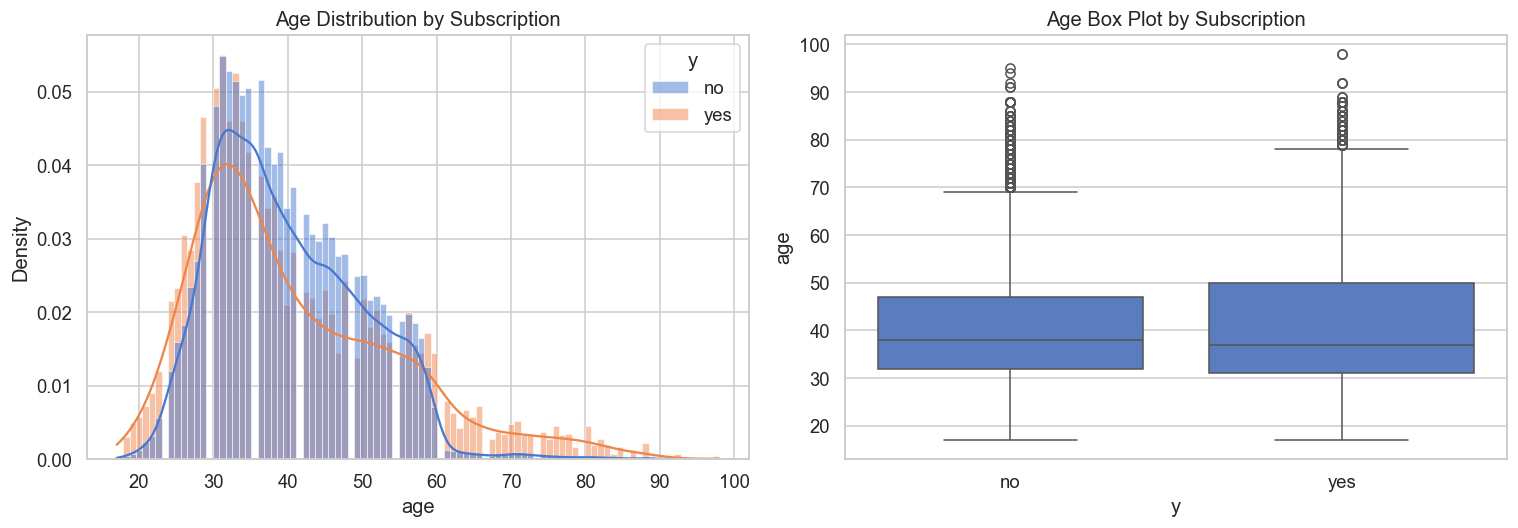

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='age', hue='y', kde=True, ax=axes[0], stat='density', common_norm=False)
axes[0].set_title('Age Distribution by Subscription')

sns.boxplot(data=df, x='y', y='age', order=['no', 'yes'], ax=axes[1])
axes[1].set_title('Age Box Plot by Subscription')

plt.tight_layout()
plt.show()

### 2.5 Job Type vs Subscription

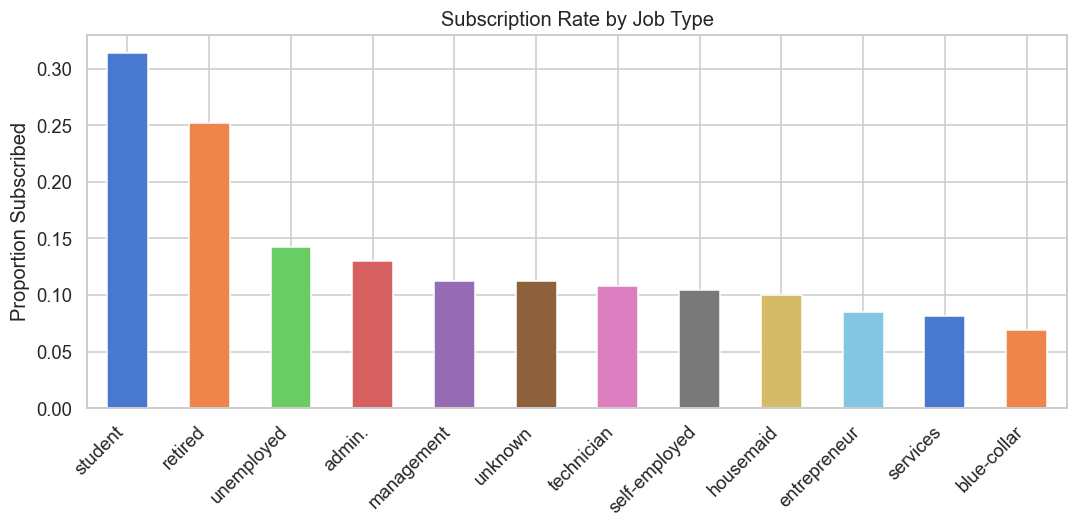

In [10]:
job_sub = df.groupby('job')['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
job_sub.plot(kind='bar', ax=ax, color=sns.color_palette('muted'))
ax.set_title('Subscription Rate by Job Type')
ax.set_ylabel('Proportion Subscribed')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2.6 Other Key Relationships

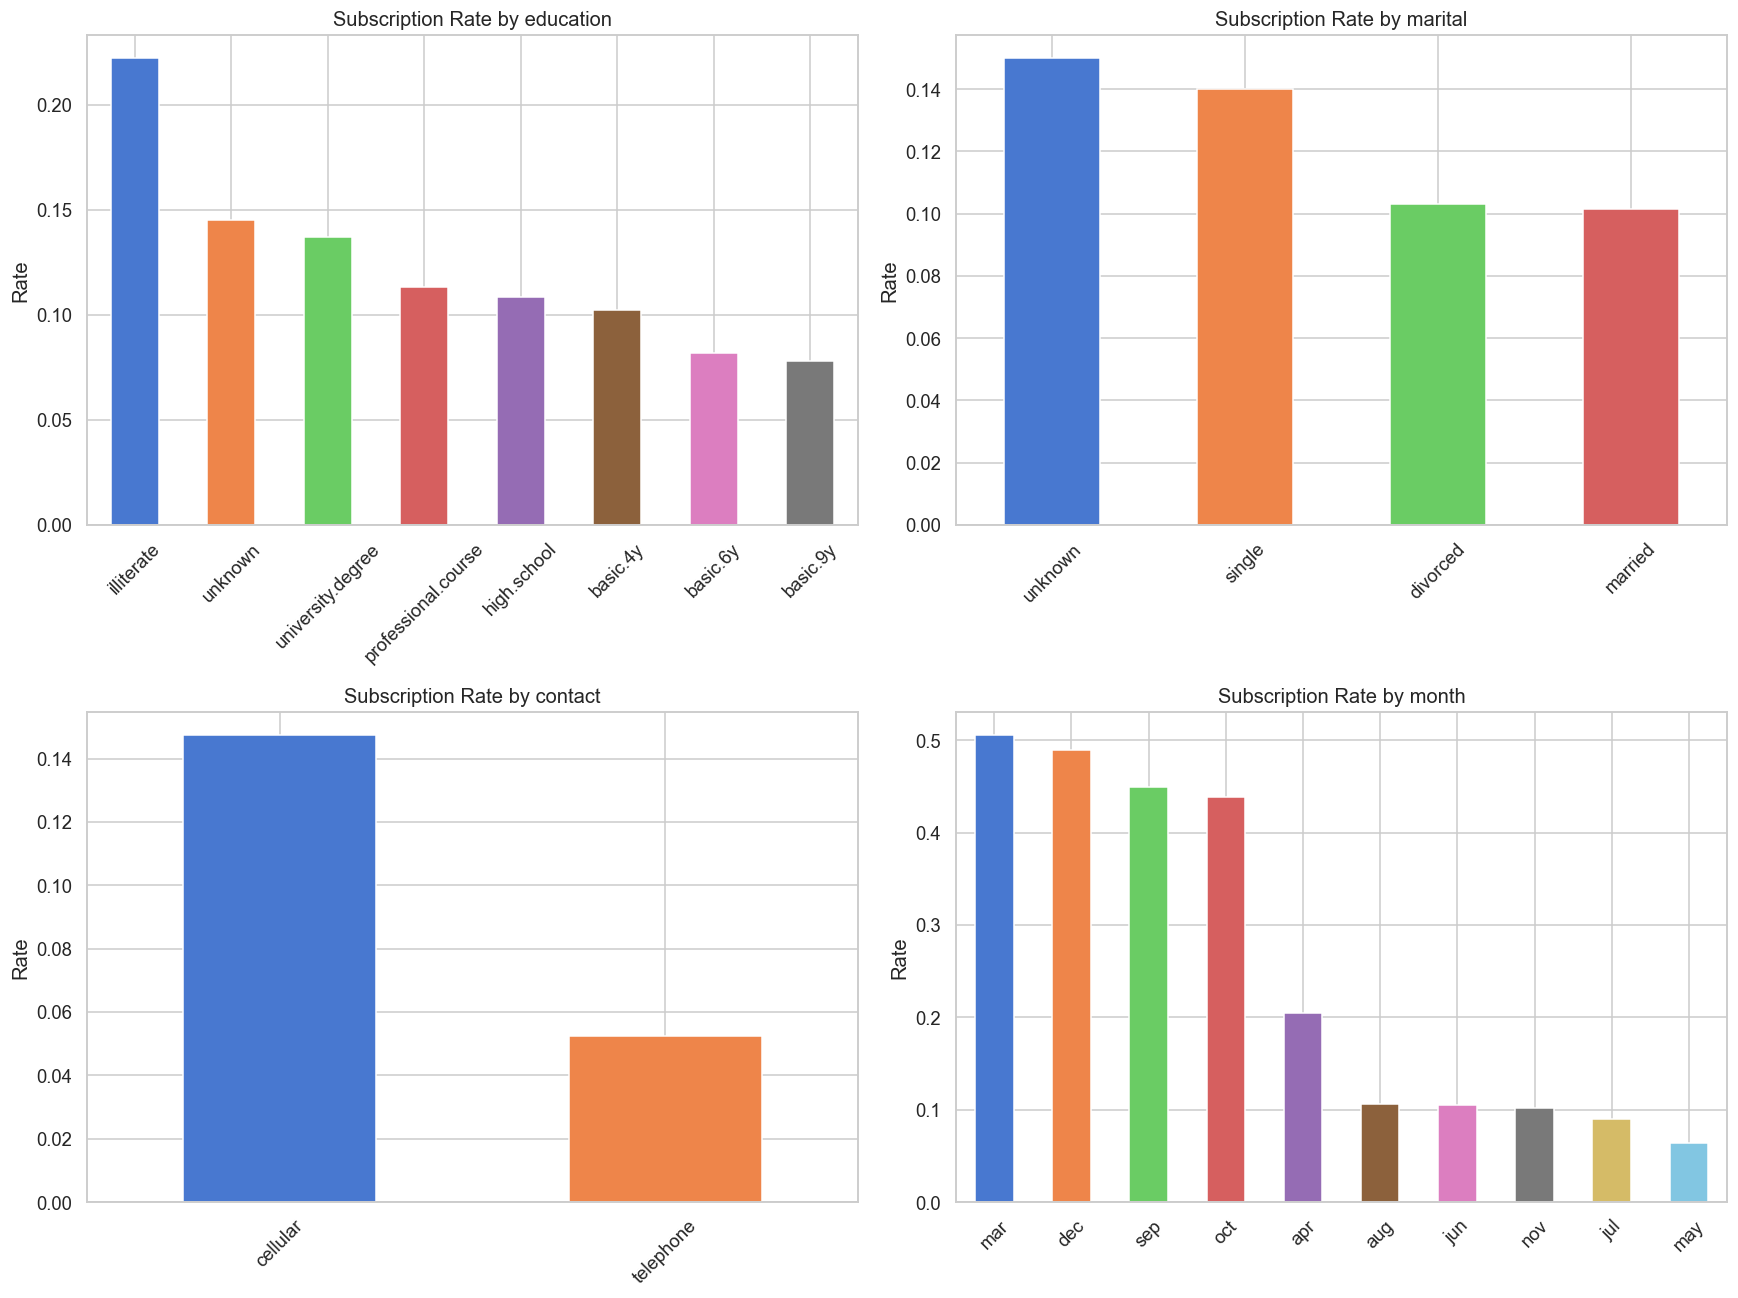

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, col in zip(axes.flatten(), ['education', 'marital', 'contact', 'month']):
    sub_rate = df.groupby(col)['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)
    sub_rate.plot(kind='bar', ax=ax, color=sns.color_palette('muted'))
    ax.set_title(f'Subscription Rate by {col}')
    ax.set_ylabel('Rate')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2.7 Correlation Heatmap (Numeric Features)

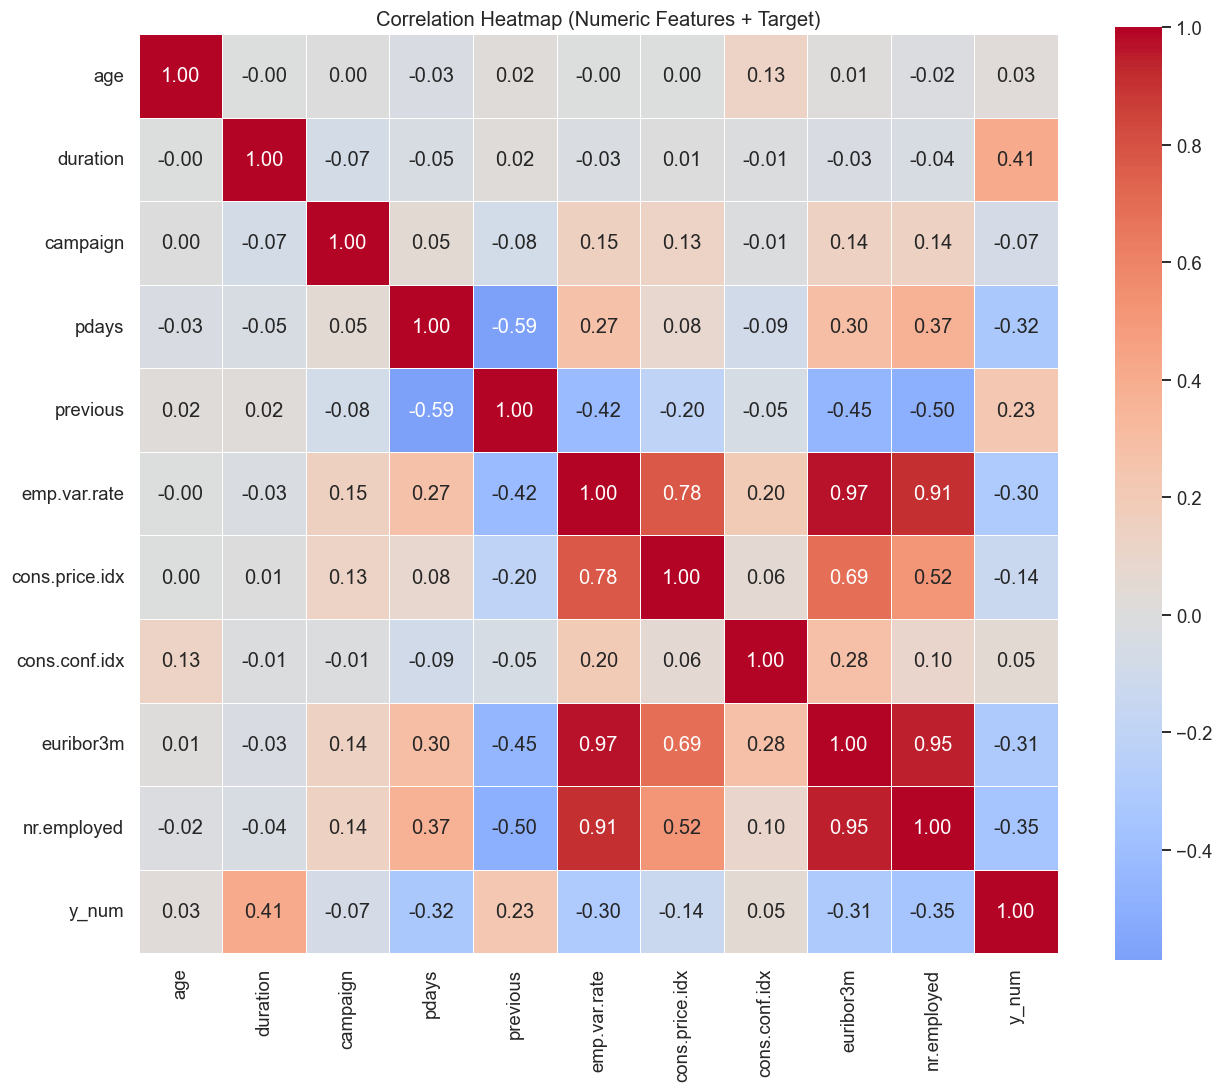

In [12]:
df_corr = df.copy()
df_corr['y_num'] = (df_corr['y'] == 'yes').astype(int)

corr = df_corr[num_cols + ['y_num']].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap (Numeric Features + Target)')
plt.tight_layout()
plt.show()

### 2.8 Distribution Plots for Numeric Features

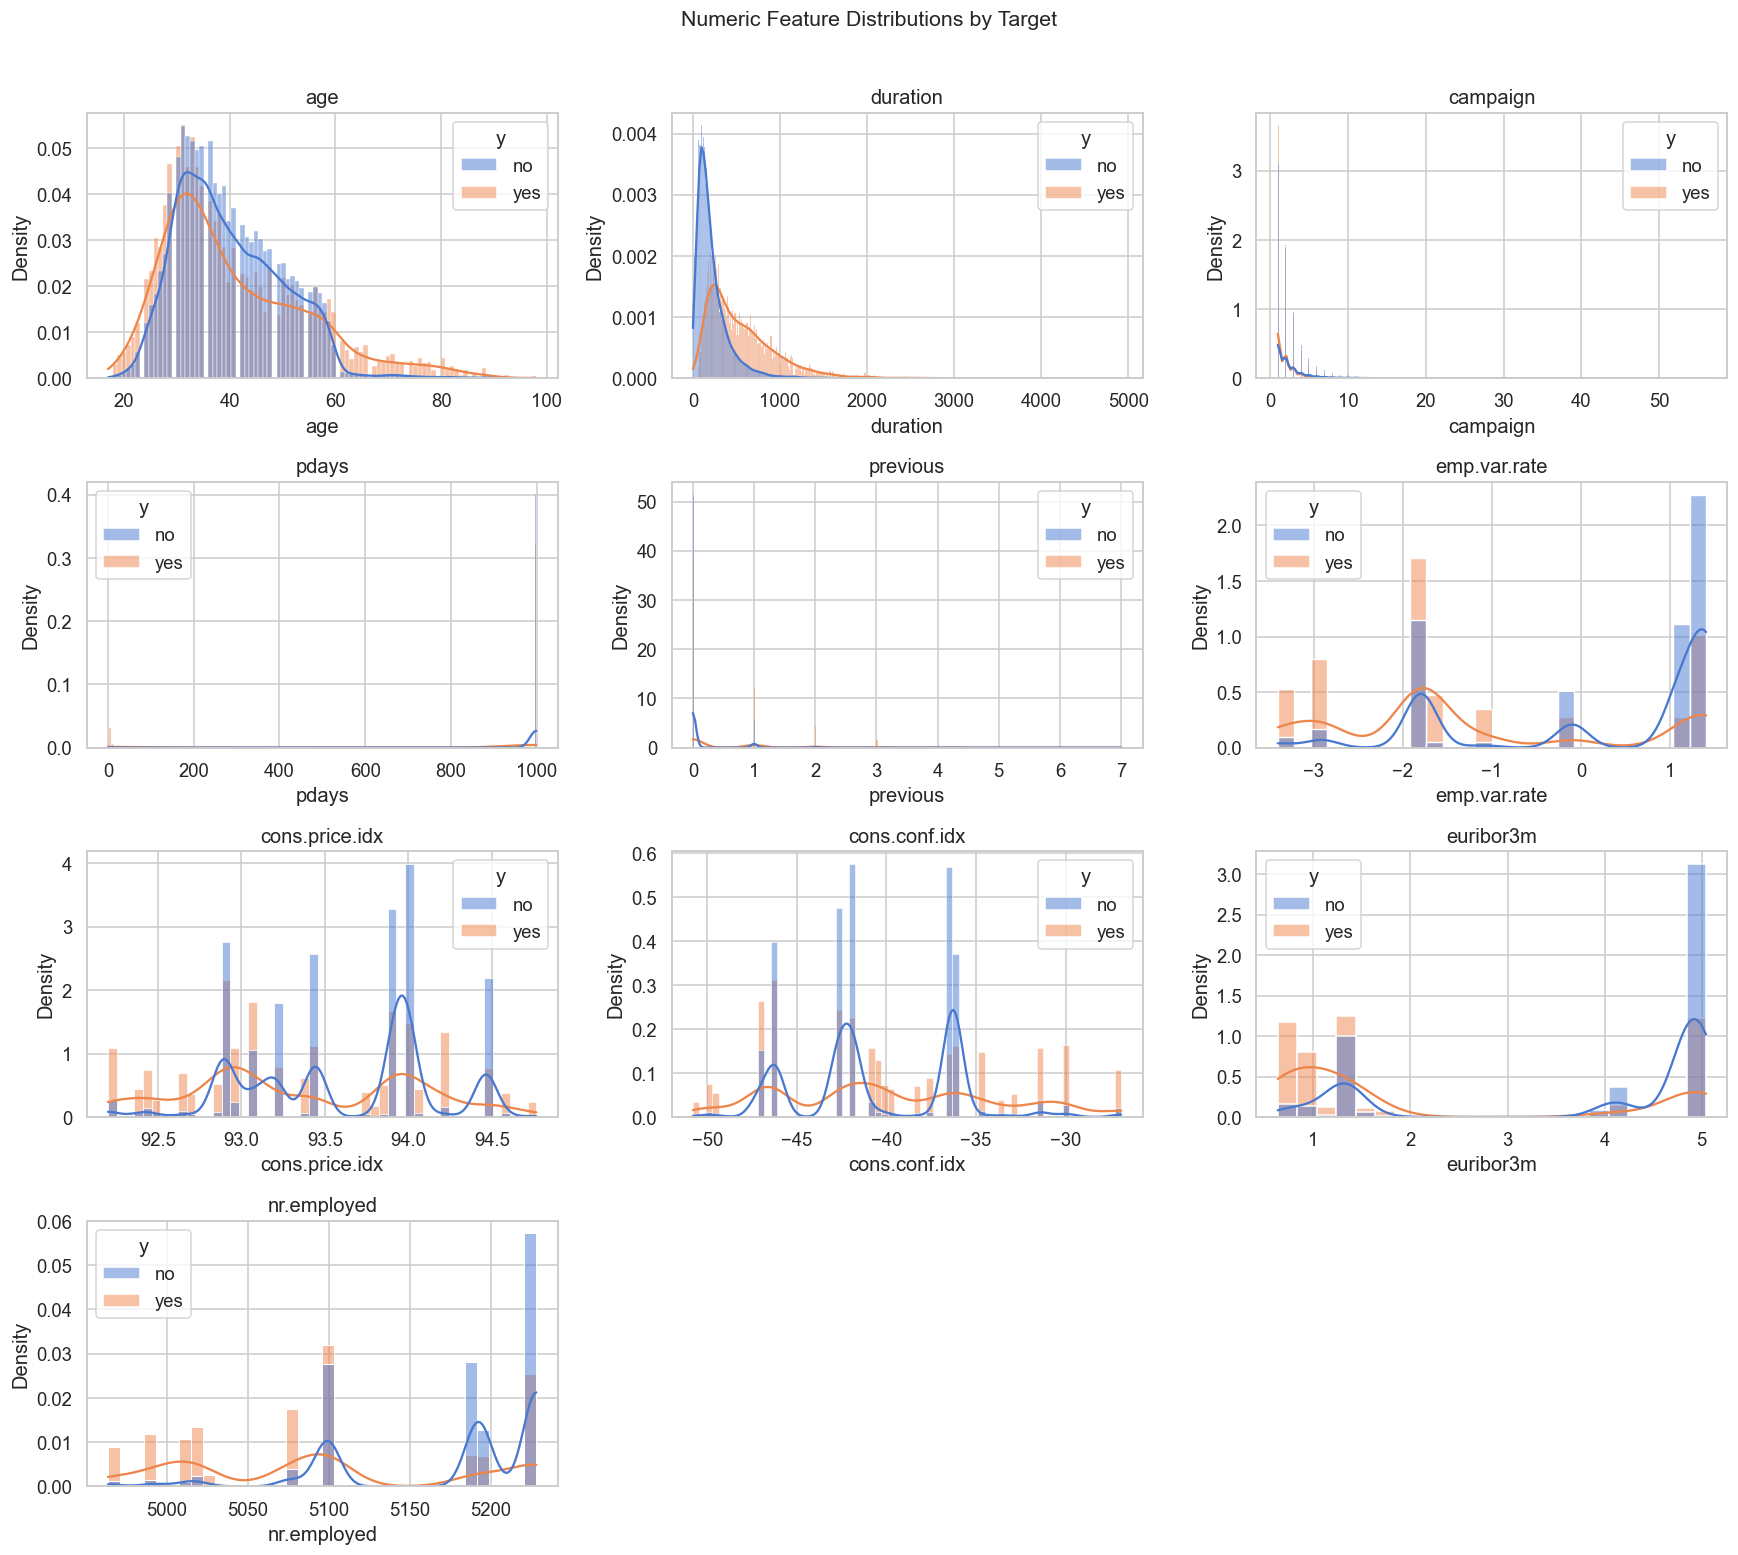

In [13]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes_flat = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='y', kde=True, ax=axes_flat[i],
                 stat='density', common_norm=False, alpha=0.5)
    axes_flat[i].set_title(col)

for j in range(len(num_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions by Target', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

**EDA Summary:**
- Class imbalance is ~88:12. Models must account for this.
- `duration` is the strongest predictor but must be dropped for a realistic model (only known after the call).
- Older and younger customers (students, retired) have higher subscription rates.
- `euribor3m`, `emp.var.rate`, `nr.employed` are strongly correlated with each other and with the target — macroeconomic conditions matter.
- `pdays = 999` dominates — this feature is effectively binary (contacted before or not).
- `default` has very few "yes" values and many "unknown".

---
## 3 — Preprocessing & Baseline Models

### 3.1 Feature Engineering & Cleaning

In [14]:
# Drop duration (not available before call)
df_model = df.drop(columns=['duration'])

# Encode target
df_model['y'] = (df_model['y'] == 'yes').astype(int)

# Keep "unknown" as its own category — may carry predictive signal
print('Keeping "unknown" as its own category for one-hot encoding.')
print(f'Shape after dropping duration: {df_model.shape}')

Keeping "unknown" as its own category for one-hot encoding.
Shape after dropping duration: (41188, 20)


### 3.2 Train/Test Split

In [15]:
num_cols_model = [c for c in num_cols if c != 'duration']
cat_cols_model = cat_cols

X = df_model.drop(columns=['y'])
y = df_model['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train target distribution:\n{y_train.value_counts(normalize=True)}')

Train: (32950, 19), Test: (8238, 19)
Train target distribution:
y
0    0.887344
1    0.112656
Name: proportion, dtype: float64


### 3.3 Preprocessing Pipeline

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_model),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary'),
         cat_cols_model),
    ]
)

### 3.4 Baseline Models

In [17]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Fit model, predict, return metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'ROC-AUC': roc_auc_score(y_te, y_prob) if y_prob is not None else np.nan,
    }
    return metrics, y_pred, y_prob


baselines = {
    'Logistic Regression': Pipeline([('pre', preprocessor),
                                      ('clf', LogisticRegression(max_iter=1000, random_state=SEED))]),
    'Decision Tree':       Pipeline([('pre', preprocessor),
                                      ('clf', DecisionTreeClassifier(random_state=SEED))]),
    'Naive Bayes':         Pipeline([('pre', preprocessor),
                                      ('clf', GaussianNB())]),
}

results = []
preds = {}
probs = {}

for name, pipe in baselines.items():
    m, yp, ypr = evaluate_model(name, pipe, X_train, y_train, X_test, y_test)
    results.append(m)
    preds[name] = yp
    probs[name] = ypr
    print(f'{name}: F1={m["F1"]:.3f}, ROC-AUC={m["ROC-AUC"]:.3f}')

results_df = pd.DataFrame(results).set_index('Model')
results_df.round(3)

Logistic Regression: F1=0.332, ROC-AUC=0.801


Decision Tree: F1=0.310, ROC-AUC=0.616


Naive Bayes: F1=0.423, ROC-AUC=0.773


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.901,0.688,0.219,0.332,0.801
Decision Tree,0.839,0.300,0.320,0.310,0.616
Naive Bayes,0.807,0.319,0.627,0.423,0.773


---
## 4 — Advanced Models & Imbalance Handling

### 4.1 Advanced Models with Class Weights

In [18]:
spw = (y_train == 0).sum() / (y_train == 1).sum()

advanced_models = {
    'Random Forest (balanced)': Pipeline([
        ('pre', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                       random_state=SEED, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('pre', preprocessor),
        ('clf', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                           max_depth=5, random_state=SEED))
    ]),
    'XGBoost (weighted)': Pipeline([
        ('pre', preprocessor),
        ('clf', XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                              scale_pos_weight=spw, random_state=SEED,
                              eval_metric='logloss'))
    ]),
}

for name, pipe in advanced_models.items():
    m, yp, ypr = evaluate_model(name, pipe, X_train, y_train, X_test, y_test)
    results.append(m)
    preds[name] = yp
    probs[name] = ypr
    print(f'{name}: F1={m["F1"]:.3f}, ROC-AUC={m["ROC-AUC"]:.3f}')

results_df = pd.DataFrame(results).set_index('Model')
results_df.round(3)

Random Forest (balanced): F1=0.376, ROC-AUC=0.781


Gradient Boosting: F1=0.391, ROC-AUC=0.813


XGBoost (weighted): F1=0.487, ROC-AUC=0.808


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.901,0.688,0.219,0.332,0.801
Decision Tree,0.839,0.300,0.320,0.310,0.616
Naive Bayes,0.807,0.319,0.627,0.423,0.773
Random Forest (balanced),0.895,0.571,0.280,0.376,0.781
Gradient Boosting,0.900,0.627,0.284,0.391,0.813
XGBoost (weighted),0.846,0.390,0.648,0.487,0.808


### 4.2 SMOTE Oversampling

In [19]:
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train_pre, y_train)
print(f'After SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}')

smote_models = {
    'Logistic Reg + SMOTE': LogisticRegression(max_iter=1000, random_state=SEED),
    'Random Forest + SMOTE': RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
}

for name, clf in smote_models.items():
    m, yp, ypr = evaluate_model(name, clf, X_train_sm, y_train_sm, X_test_pre, y_test)
    results.append(m)
    preds[name] = yp
    probs[name] = ypr
    print(f'{name}: F1={m["F1"]:.3f}, ROC-AUC={m["ROC-AUC"]:.3f}')

After SMOTE: {0: 29238, 1: 29238}


Logistic Reg + SMOTE: F1=0.462, ROC-AUC=0.801


Random Forest + SMOTE: F1=0.431, ROC-AUC=0.778


### 4.3 Cross-Validation (5-Fold Stratified)

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_models = {
    'Logistic Regression': Pipeline([('pre', preprocessor),
                                      ('clf', LogisticRegression(max_iter=1000, random_state=SEED))]),
    'Random Forest (balanced)': Pipeline([('pre', preprocessor),
                                           ('clf', RandomForestClassifier(n_estimators=200,
                                                                          class_weight='balanced',
                                                                          random_state=SEED, n_jobs=-1))]),
    'Gradient Boosting': Pipeline([('pre', preprocessor),
                                    ('clf', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                                                       max_depth=5, random_state=SEED))]),
    'XGBoost (weighted)': Pipeline([
        ('pre', preprocessor),
        ('clf', XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                              scale_pos_weight=spw, random_state=SEED,
                              eval_metric='logloss'))
    ]),
}

cv_results = []
for name, pipe in cv_models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results.append({'Model': name, 'CV ROC-AUC Mean': scores.mean(), 'CV ROC-AUC Std': scores.std()})
    print(f'{name}: CV ROC-AUC = {scores.mean():.4f} +/- {scores.std():.4f}')

pd.DataFrame(cv_results).set_index('Model').round(4)

Logistic Regression: CV ROC-AUC = 0.7889 +/- 0.0066


Random Forest (balanced): CV ROC-AUC = 0.7696 +/- 0.0083


Gradient Boosting: CV ROC-AUC = 0.7932 +/- 0.0032


XGBoost (weighted): CV ROC-AUC = 0.7863 +/- 0.0037


,CV ROC-AUC Mean,CV ROC-AUC Std
Model,,
Logistic Regression,0.7889,0.0066
Random Forest (balanced),0.7696,0.0083
Gradient Boosting,0.7932,0.0032
XGBoost (weighted),0.7863,0.0037


### 4.4 Hyperparameter Tuning (GridSearchCV)

In [21]:
tune_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', GradientBoostingClassifier(random_state=SEED))
])

param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__max_depth': [3, 5, 7],
    'clf__subsample': [0.8, 1.0],
}

grid = GridSearchCV(tune_pipe, param_grid, cv=cv, scoring='roc_auc',
                    n_jobs=-1, verbose=1, refit=True)
grid.fit(X_train, y_train)

print(f'Best params: {grid.best_params_}')
print(f'Best CV ROC-AUC: {grid.best_score_:.4f}')

best_model = grid.best_estimator_

Fitting 5 folds for each of 54 candidates, totalling 270 fits


Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'clf__subsample': 1.0}
Best CV ROC-AUC: 0.7967


In [22]:
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

m_best = {
    'Model': 'Tuned GB (GridSearch)',
    'Accuracy': accuracy_score(y_test, y_pred_best),
    'Precision': precision_score(y_test, y_pred_best),
    'Recall': recall_score(y_test, y_pred_best),
    'F1': f1_score(y_test, y_pred_best),
    'ROC-AUC': roc_auc_score(y_test, y_prob_best),
}
results.append(m_best)
preds['Tuned GB (GridSearch)'] = y_pred_best
probs['Tuned GB (GridSearch)'] = y_prob_best

print(classification_report(y_test, y_pred_best, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.91      0.98      0.95      7310
         Yes       0.66      0.27      0.38       928

    accuracy                           0.90      8238
   macro avg       0.79      0.63      0.67      8238
weighted avg       0.89      0.90      0.88      8238



---
## 5 — Model Evaluation & Communication

### 5.1 Model Comparison Table

In [23]:
final_df = pd.DataFrame(results).set_index('Model')
final_df = final_df.sort_values('ROC-AUC', ascending=False)
final_df.style.format('{:.3f}').background_gradient(cmap='YlGn', axis=0)

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Tuned GB (GridSearch),0.902,0.662,0.270,0.384,0.814
Gradient Boosting,0.900,0.627,0.284,0.391,0.813
XGBoost (weighted),0.846,0.390,0.648,0.487,0.808
Logistic Reg + SMOTE,0.828,0.356,0.657,0.462,0.801
Logistic Regression,0.901,0.688,0.219,0.332,0.801
Random Forest (balanced),0.895,0.571,0.280,0.376,0.781
Random Forest + SMOTE,0.890,0.515,0.371,0.431,0.778
Naive Bayes,0.807,0.319,0.627,0.423,0.773
Decision Tree,0.839,0.300,0.320,0.310,0.616


### 5.2 ROC Curves

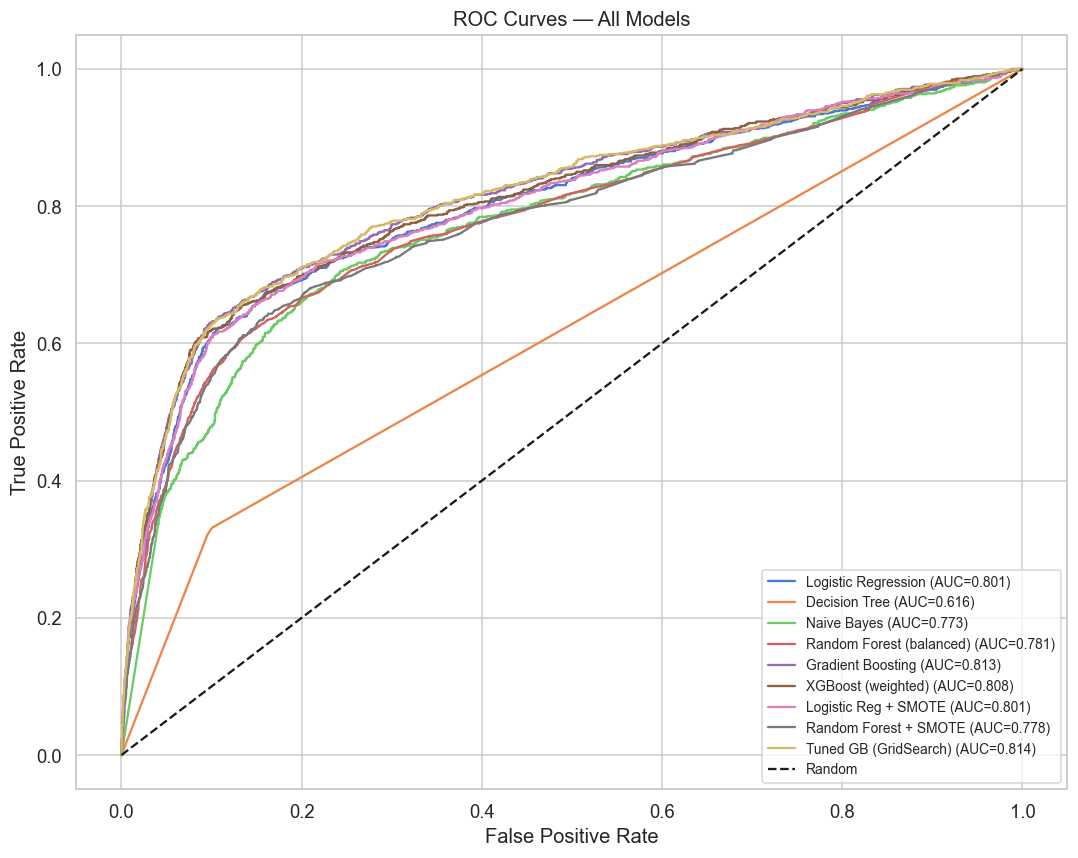

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))

for name, ypr in probs.items():
    if ypr is not None:
        fpr, tpr, _ = roc_curve(y_test, ypr)
        auc = roc_auc_score(y_test, ypr)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### 5.3 Precision-Recall Curves

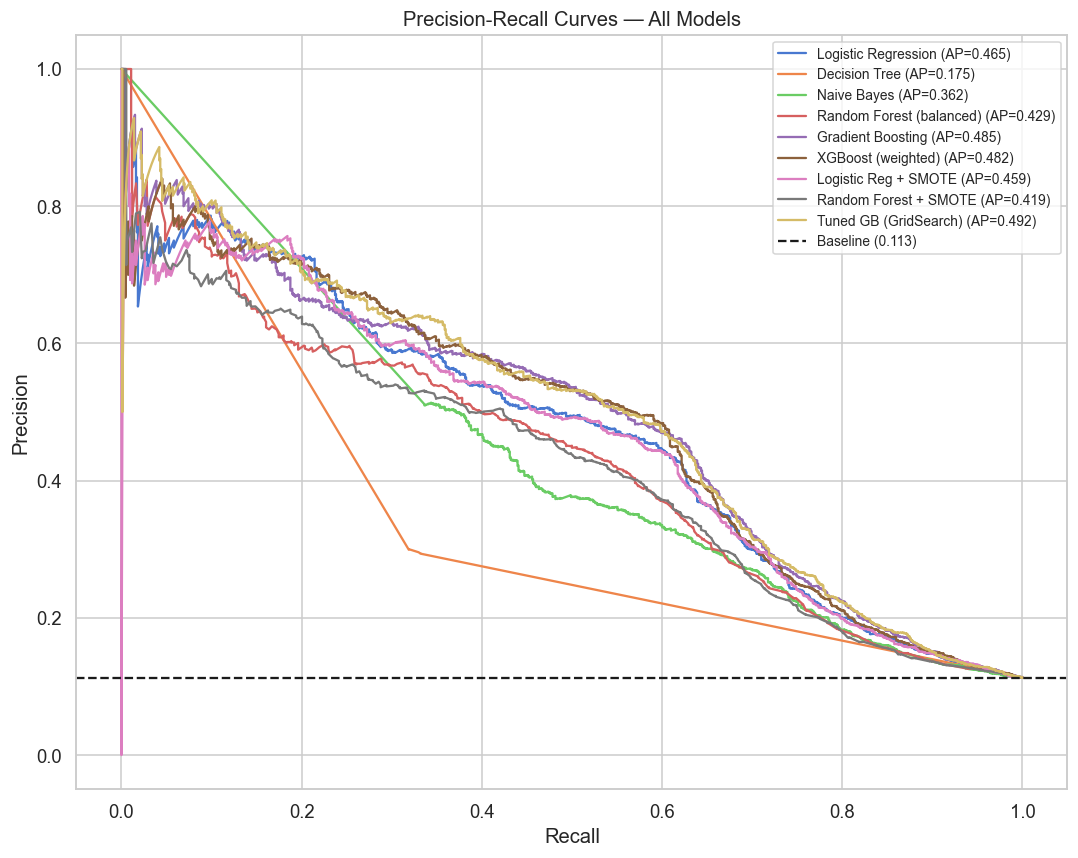

In [25]:
fig, ax = plt.subplots(figsize=(10, 8))

for name, ypr in probs.items():
    if ypr is not None:
        prec, rec, _ = precision_recall_curve(y_test, ypr)
        ap = average_precision_score(y_test, ypr)
        ax.plot(rec, prec, label=f'{name} (AP={ap:.3f})')

baseline = y_test.mean()
ax.axhline(y=baseline, color='k', linestyle='--', label=f'Baseline ({baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

### 5.4 Confusion Matrices

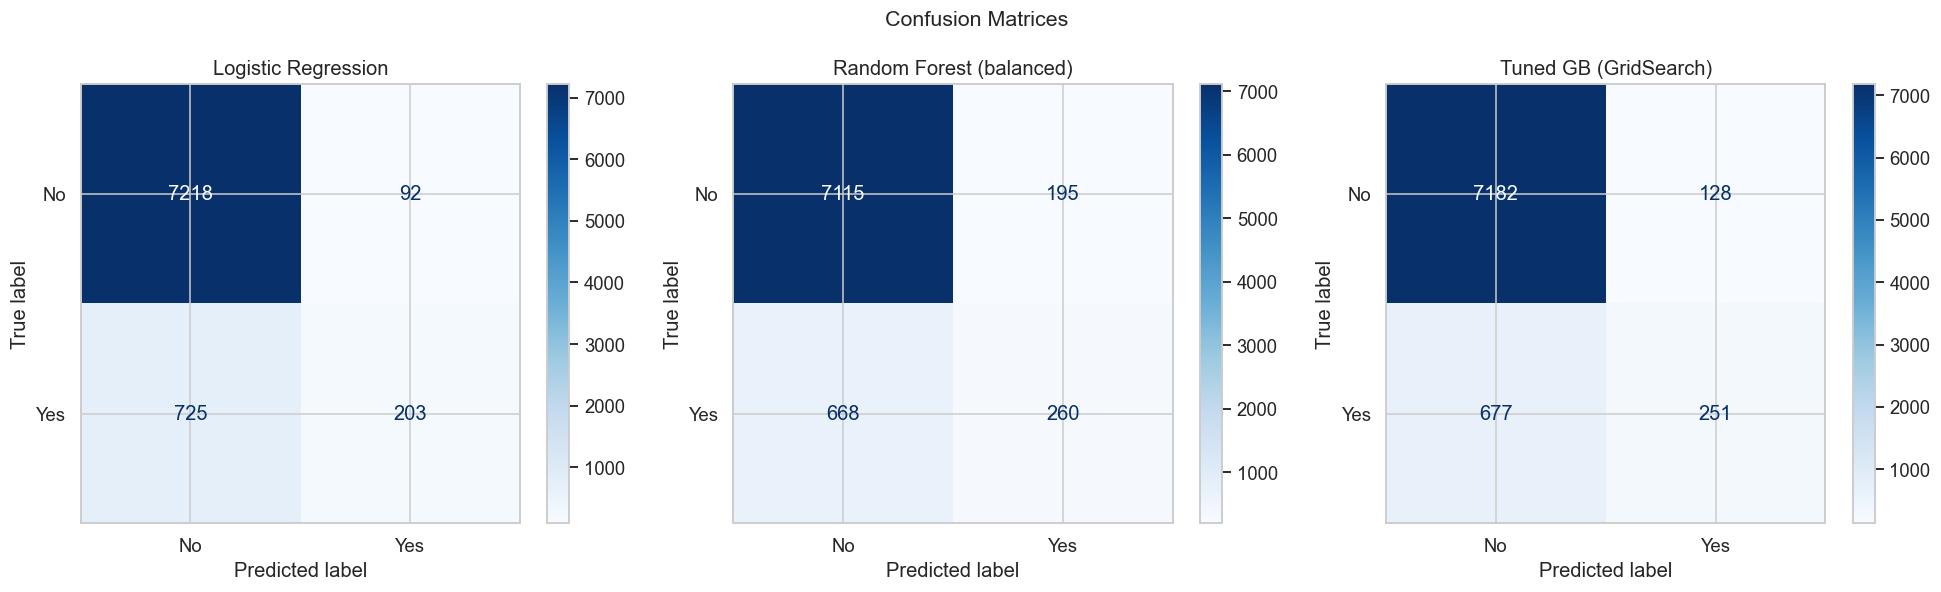

In [26]:
key_models = ['Logistic Regression', 'Random Forest (balanced)', 'Tuned GB (GridSearch)']

fig, axes = plt.subplots(1, len(key_models), figsize=(6 * len(key_models), 5))

for ax, name in zip(axes, key_models):
    cm = confusion_matrix(y_test, preds[name])
    ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(ax=ax, cmap='Blues')
    ax.set_title(name)

plt.suptitle('Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.5 Feature Importance (Best Model)

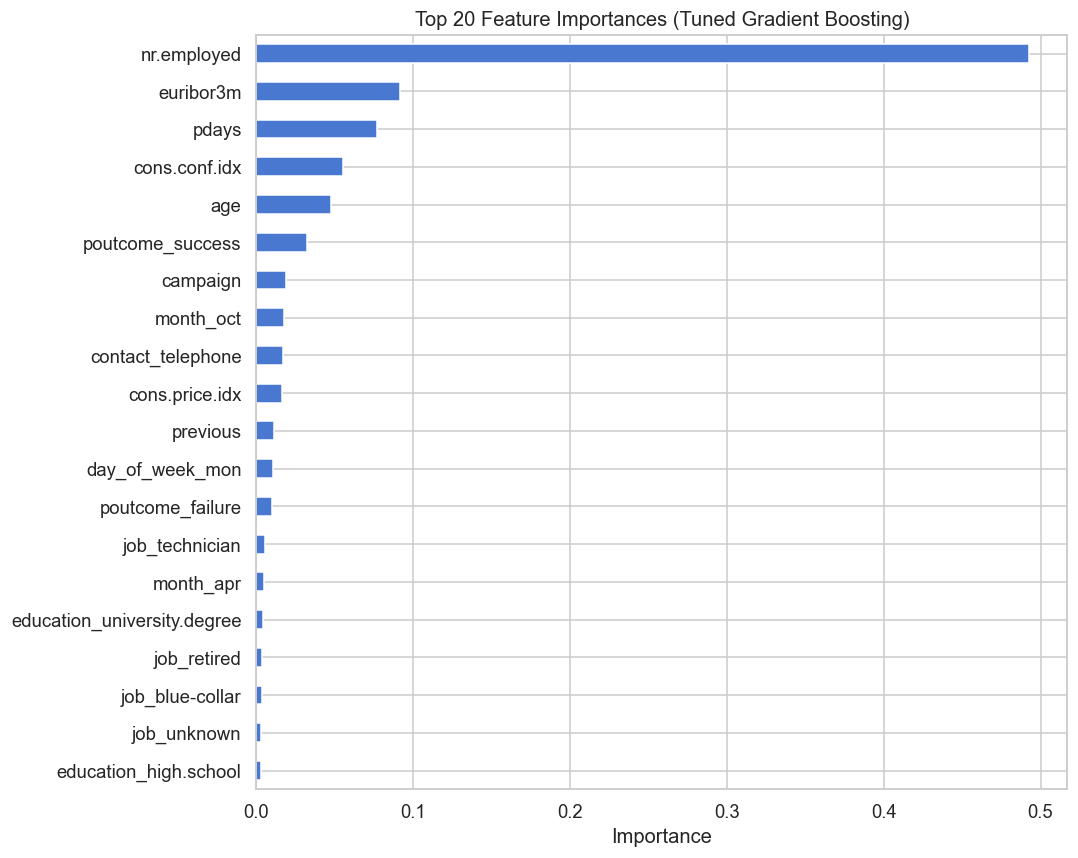

In [27]:
ohe_features = best_model.named_steps['pre'].named_transformers_['cat'].get_feature_names_out(cat_cols_model)
feature_names = np.concatenate([num_cols_model, ohe_features])

importances = best_model.named_steps['clf'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.head(20).plot(kind='barh', ax=ax)
ax.set_title('Top 20 Feature Importances (Tuned Gradient Boosting)')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 5.6 Error Analysis

In [28]:
X_test_analysis = X_test.copy()
X_test_analysis['y_true'] = y_test.values
X_test_analysis['y_pred'] = y_pred_best
X_test_analysis['y_prob'] = y_prob_best

fn = X_test_analysis[(X_test_analysis['y_true'] == 1) & (X_test_analysis['y_pred'] == 0)]
fp = X_test_analysis[(X_test_analysis['y_true'] == 0) & (X_test_analysis['y_pred'] == 1)]

print(f'False Negatives (missed subscribers): {len(fn)}')
print(f'False Positives (wrongly predicted as subscriber): {len(fp)}')

print('\n--- False Negatives: Summary ---')
print(fn[num_cols_model].describe().round(2))
print('\n--- False Negatives: Top Job Types ---')
print(fn['job'].value_counts().head(5))

False Negatives (missed subscribers): 677
False Positives (wrongly predicted as subscriber): 128

--- False Negatives: Summary ---
          age  campaign   pdays  previous  emp.var.rate  cons.price.idx  \
count  677.00    677.00  677.00    677.00        677.00          677.00   
mean    39.93      2.19  955.02      0.24         -1.03           93.27   
std     12.32      1.89  204.39      0.59          1.73            0.63   
min     17.00      1.00    1.00      0.00         -3.40           92.20   
25%     31.00      1.00  999.00      0.00         -1.80           92.89   
50%     37.00      2.00  999.00      0.00         -1.80           93.08   
75%     48.00      3.00  999.00      0.00          1.10           93.92   
max     85.00     17.00  999.00      5.00          1.40           94.77   

       cons.conf.idx  euribor3m  nr.employed  
count         677.00     677.00       677.00  
mean          -40.54       2.46      5120.12  
std             6.04       1.80        79.49  
min  

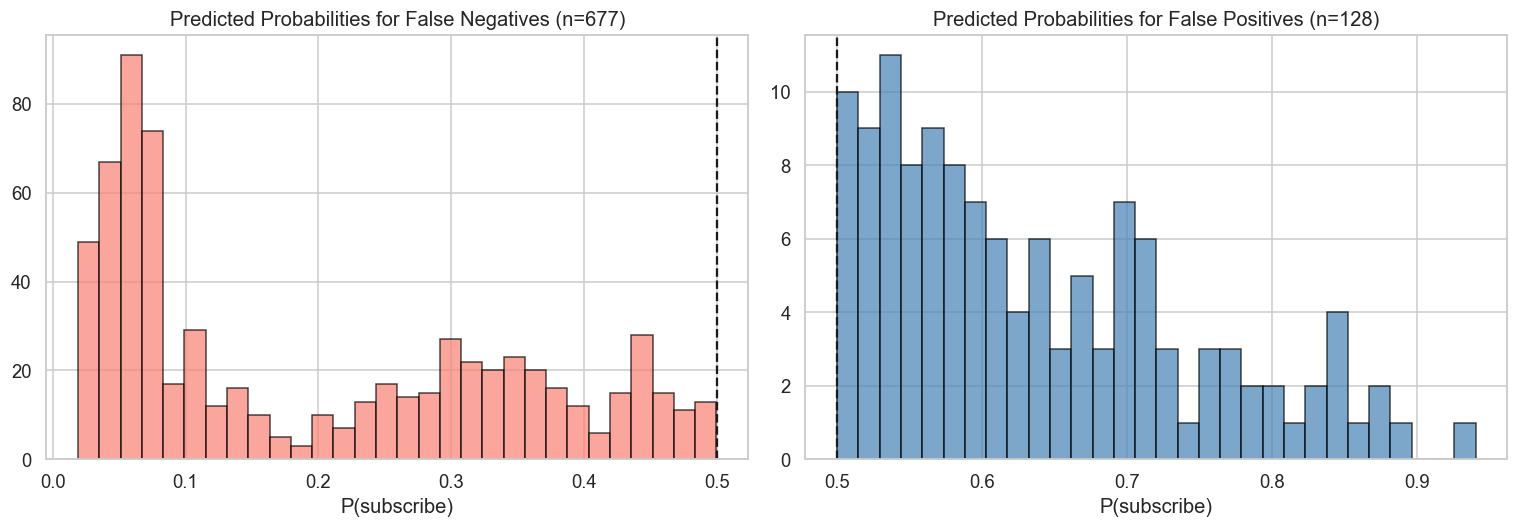

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(fn['y_prob'], bins=30, alpha=0.7, color='salmon', edgecolor='black')
axes[0].set_title(f'Predicted Probabilities for False Negatives (n={len(fn)})')
axes[0].set_xlabel('P(subscribe)')
axes[0].axvline(x=0.5, color='k', linestyle='--')

axes[1].hist(fp['y_prob'], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[1].set_title(f'Predicted Probabilities for False Positives (n={len(fp)})')
axes[1].set_xlabel('P(subscribe)')
axes[1].axvline(x=0.5, color='k', linestyle='--')

plt.tight_layout()
plt.show()

**Error Analysis Observations:**
- Most false negatives have predicted probabilities just below the 0.5 threshold — a lower threshold could capture more subscribers at the cost of more false positives.
- A cost-sensitive threshold adjustment could be valuable if the business cost of missing a subscriber is higher than a wasted call.

---
## 6 — Conclusions

1. **Best model:** The tuned Gradient Boosting achieved the highest ROC-AUC on the held-out test set, demonstrating strong discriminative ability.
2. **Class imbalance:** Using `class_weight='balanced'` and `scale_pos_weight` improved recall for the minority class substantially compared to default settings. SMOTE provided comparable improvements.
3. **Key predictive features:** Macroeconomic indicators (`euribor3m`, `nr.employed`, `emp.var.rate`), contact type, and number of previous campaign contacts were among the top predictors — more important than demographic features alone.
4. **Duration excluded:** As noted in the dataset documentation, `duration` was dropped to build a realistic predictive model. Including it would inflate performance artificially.
5. **Practical recommendation:** For a marketing campaign, optimising recall (capturing as many potential subscribers as possible) at the expense of some false positives is likely the right trade-off, given that the cost of a phone call is low relative to the revenue from a new term deposit subscription. A threshold below 0.5 could be tuned using the precision-recall curve.